In [1]:
# Load model directly
import argparse
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
from copy import deepcopy
import re
from nltk.translate.bleu_score import sentence_bleu
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import AutoTokenizer, BertForMaskedLM, BertConfig

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.nn.functional import cross_entropy
from torch.utils.data import TensorDataset, Dataset, DataLoader
from torch.utils.data import DataLoader, Subset, RandomSampler
torch.set_default_dtype(torch.float32)
import tensorflow_hub as hub

from utils import *

/usa/taikun/miniconda3/envs/03_transf_py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-10-15 09:46:44.818184: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-15 09:46:44.958167: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-15 09:46:45.031745: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10

GPU usage:
  memory.used memory.free
0    8261 MiB   15986 MiB
1       4 MiB   24241 MiB
Returning GPU1 with  24241 free MiB
cuda:1


## Read Data from txt Files

In [2]:
# For MNLI matched Val Set
# dataName='mnli_matched_val'
# dataPath='/usa/taikun/07_transencoder/MNLI/mnli/mnli_matched.txt'
# tgt_model_name="BERT_MNLI"
# tgtModel="textattack/bert-base-uncased-MNLI"
# tgt_model_name='SBERT_NLI'
# tgtModel='cross-encoder/nli-roberta-base'
## premise accuracy 0.576
## hyp accuracy 0.48
# tgt_model_name="ROBERTA_MNLI"
# tgtModel="textattack/roberta-base-MNLI"
## premise accuracy 0.573
## hyp accuracy 0.508
# ---------------------------------------- #

# # Read MNLI mismatched Val Set
dataName='mnli_mismatched_val'
dataPath='/usa/taikun/07_transencoder/MNLI/mnli/mnli_mismatched.txt'
# tgt_model_name="BERT_MNLI"
# tgtModel="textattack/bert-base-uncased-MNLI"
# tgt_model_name='SBERT_NLI'
# tgtModel='cross-encoder/nli-roberta-base'
# premise accuracy 0.581
# hyp
tgt_model_name="ROBERTA_MNLI"
tgtModel="textattack/roberta-base-MNLI"
# premise 
# hyp
# ---------------------------------------- #

# # Read SNLI Val Set
# dataName='snli_val'
# dataPath='/usa/taikun/07_transencoder/3datasets/snli/snli/snli.txt'
# tgt_model_name="BERT_MNLI"
# tgtModel="textattack/bert-base-uncased-snli"
# # tgtModel="pepa/roberta-base-snli"

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
vocabSize = tokenizer.vocab_size
print(f"Vocabulary Size: {vocabSize}")

texts_, labels_ = read_corpus(path = dataPath, tokenizer = tokenizer, clean=True, MR=False,\
    lower=False, dataName=dataName, dataPath=dataPath, tgtModel_name=tgt_model_name)

print(texts_[:3])
print(labels_[:3])

Vocabulary Size: 28996
ROBERTA_MNLI
[("You ca n't take it with you -- neither can I , unfortunately .", 'You are not able to bring it with you .'), ('The publisher sent unrevised bound proofs from which this review was prepared ; unfortunately , there was no proof of an index , but the publisher has assured me that there will be one in the published book , a rather essential ingredient of a work with this title .', 'Having an index in a book is very important .'), ("So after two or three days he called Callgrove and said , Do n't bother coming in I found a guy better than you .", 'He called up Callgrove to give him a raise .')]
[2, 1, 0]


/usa/taikun/miniconda3/envs/03_transf_py311/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## Read Data from json File

In [3]:
import pandas as pd

# SNLI premise
# evaluation_partition = '/usa/taikun/07_transencoder/2evaluation/snli/premise/eva_0926_205930_premise_BERTFineTuned_SBERT_NLI_snli_val_0.7_8_60_0.json'

# SNLI hypothesis
# evaluation_partition = '/usa/taikun/07_transencoder/2evaluation/snli/hypothesis/eva_0926_205952_hypothesis_BERTFineTuned_SBERT_NLI_snli_val_0.7_8_40_0.json'

# MNLI premise
# evaluation_partition = '/usa/taikun/07_transencoder/2evaluation/mnli/premise/eva_0923_020243BERTMaskedLM_BERT_MNLI_mnli_matched_val_0.7_8_60_0.json'
# evaluation_partition = '/usa/taikun/07_transencoder/2evaluation/mnli/premise/archive0922/evaluation_0.9_2_1000_2.6550_BERTFineTuned_ROBERTA_MNLI_mnli_matched_val_0.7_8_80_0.json'
# evaluation_partition = '/usa/taikun/07_transencoder/2evaluation/mnli/premise/eva_0926_210112BERTFineTuned_SBERT_NLI_mnli_matched_val_0.7_8_60_0.json'

# MNLI hypothesis
# evaluation_partition = '/usa/taikun/07_transencoder/2evaluation/mnli/hypothesis/eva_0922_103259BERTMaskedLM_BERT_MNLI_mnli_matched_val_0.7_8_40_0.json'
# evaluation_partition = '/usa/taikun/07_transencoder/2evaluation/mnli/hypothesis/eva_0926_210135BERTFineTuned_SBERT_NLI_mnli_matched_val_0.7_8_40_0.json'

# MNLI mismatched premise
# evaluation_partition = '/usa/taikun/07_transencoder/2evaluation/mnli_mismatched/premise/eva_0927_144616BERTFineTuned_SBERT_NLI_mnli_mismatched_val_0.7_8_60_0.json'
evaluation_partition = '/usa/taikun/07_transencoder/2evaluation/mnli_mismatched/premise/eva_0923_022746_BERTFineTuned_BERT_MNLI_mnli_mismatched_val_0.7_8_60_0.json'

# MNLI mismatched hypothesis
# evaluation_partition = '/usa/taikun/07_transencoder/2evaluation/mnli_mismatched/hypothesis/eva_0928_204019BERTFineTuned_SBERT_NLI_mnli_mismatched_val_0.7_8_40_0.json'


df = pd.read_json(evaluation_partition)
df.head(3)


src_texts = df['sourceDocs'].tolist()
adv_texts = df['advDocs']
adv_texts_ = [(t[0],t[1]) for t in adv_texts]

print(src_texts[:2])
print(adv_texts_[:2])
print(labels_[:2])



[["You can't take it with you - - neither can I, unfortunately. ", ' You are not able to bring it with you.'], ['The publisher sent unrevised bound proofs from which this review was prepared ; unfortunately, there was no proof of an index, but the publisher has assured me that there will be one in the published book, a rather essential ingredient of a work with this title. ', ' Having an index in a book is very important.']]
[("You ca n'Clifford take it with you - - neither can I, unfortunately. ", ' You are not able to bring it with you.'), ('The publisher sent unrevised bound proofs from which this review was prepared ; unfortunately, there was no proof of an index, but the publisher has assured me that there will be one in the published book, a rather essential ingredient of a work with this title. ', ' Having an index in a book is very important.')]
[2, 1]


## Evaluaiton on non-SBERT

In [4]:
texts_ = adv_texts_

total = 0
sprobs, slabels = [], []

for sample_inx in range(len(texts_)): # batch size is 1
    if total % 200 == 0:
        print(total," th document.")
    total += 1
    text = texts_[sample_inx]
    label = labels_[sample_inx]
    # print("text", text)
    # print("label", label)
# replace machanism
    sLabels, sProbs = query([text], tgtModel=tgtModel)  # st [bs=1, trueDocLen]
    
    slabels.append(sLabels.item())
    sprobs.append(sProbs)
    
    # if total == 10:
    #     print(total," th document.")
    #     break
    

0  th document.


/usa/taikun/miniconda3/envs/03_transf_py311/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of the model checkpoint at textattack/roberta-base-MNLI were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to 

RuntimeError: CUDA error: CUDA-capable device(s) is/are busy or unavailable
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## attack on SEBRT

In [ ]:
# # evaluation on sentence-bert
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# import torch

# nums_samples_inference = 2
# texts_ = texts_[:nums_samples_inference]
# labels_ = labels_[:nums_samples_inference]

# model = AutoModelForSequenceClassification.from_pretrained('cross-encoder/nli-roberta-base')
# tokenizer = AutoTokenizer.from_pretrained('cross-encoder/nli-roberta-base')

# # features = tokenizer(['A man is eating pizza', 'A black race car starts up in front of a crowd of people.'], ['A man eats something', 'A man is driving down a lonely road.'],  padding=True, truncation=True, return_tensors="pt")
# processed_texts = [[sample[0], sample[1]] for sample in texts_]
# features = tokenizer(processed_texts,  padding=True, truncation=True, return_tensors="pt")

# # if tgtModel == 'ROBERTA_SNLI':
# #     print("ROBERTA_SNLI")
# #     mapping = {'contradiction': 2, 'entailment': 0, 'neutral': 1}

# # elif tgtModel == 'ROBERTA_MNLI':
# #     print("ROBERTA_MNLI")
# #     mapping = {'contradiction': 0, 'entailment': 2, 'neutral': 1}
    
# # else:
# #     print("BERT_UNCASED")
# #     mapping = {'contradiction': 0, 'entailment': 1, 'neutral': 2}

# model.eval()
# with torch.no_grad():
#     scores = model(**features).logits
#     print(scores)

#     label_mapping = ['contradiction', 'entailment', 'neutral']
#     labels = [label_mapping[score_max] for score_max in scores.argmax(dim=1)]
#     print(labels)
#     slabels = [mapping[l] for l in labels]
#     print(slabels)

In [ ]:
# # For MNLI mismatched Val Set
# startFromSample = 0

# dataName='mnli_mismatched_val'
# dataPath='/usa/taikun/07_transencoder/MNLI/mnli/mnli_mismatched.txt'
# importantTokensFile='/usa/taikun/07_transencoder/0dataProcessing/mnli/tokens_mnli_mismatched_val_0.json_hypothesis.json'
# tgtModel="textattack/bert-base-uncased-MNLI"
# tgt_model_name="BERT_MNLI"

# attackerName='BERTFineTuned'
# # attackerPath='/usa/taikun/07_transencoder/MNLI/attackerModels/' 
# numsAttackedTokens=0.7
# maxLenDoc=512

# alpha=0.7

# attackerFile='/usa/taikun/07_transencoder/1training/mnli/hypothesis/9Sep/attacker_mnlimatched_0.5_1_500_3.1694.pth'
# numCandidatesEachToken=80 # total numbers of desire attacked tokens
# numsMaxCandidates=8
# ifPrintAttackProcess=True

# mode = 'nli'
# #on='premise'
# on='hypothesis'

# evaluationPartition= 'temp.json'

# tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
# vocabSize = tokenizer.vocab_size
# print(f"Vocabulary Size: {vocabSize}")

# # texts_, labels_ = read_corpus(path = dataPath, tokenizer = tokenizer, clean=True, MR=False,\
# #     lower=False, dataName=dataName, dataPath=dataPath, tgtModel_name=tgt_model_name)

# # print(texts_[:3])
# # print(labels_[:3])

In [ ]:
# text = [('Luis Alonso, Luis Alonso, says to him, Luis Alonso\'s friend.', 'They said they do not know the man.'),
#         ('Luis Alonso, Luis Alonso, says to him, Luis Alonso\'s friend.', 'hey said they do graphical know the man.')]

# sLabels, sProbs = query(text, tgtModel=tgtModel)  # st [bs=1, trueDocLen]
# print(sLabels)
# print(sProbs)

In [ ]:

# # For MNLI matched Val Set
# dataName='mnli_matched_val'
# dataPath='/usa/taikun/07_transencoder/MNLI/mnli/mnli_matched.txt'
# # tgtModel='textattack/bert-base-uncased-MNLI'
# # tgtModel='Alireza1044/albert-base-v2-mnli'
# tgtModel="textattack/roberta-base-MNLI"

# attackerName='BERTMaskedLM'
# attackerPath='None' 
# numsAttackedTokens=1.0
# maxLenDoc=512

# alpha=-0.99

# mode = 'nli'
# attackerFile='None'
# numCandidatesEachToken=150 # total numbers of desire attacked tokens
# numsMaxCandidates=10
# ifPrintAttackProcess=True
# evaluationPartition="None"

# startFromSample=0
# numsProcessedSamples= 1000


# # ### 1.2 Tokenize Dataset
# # examples is list[str]
# # max_length is int
# tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
# vocabSize = tokenizer.vocab_size
# print(f"Vocabulary Size: {vocabSize}")

# texts_, labels_ = read_corpus(path = dataPath, tokenizer = tokenizer, clean=True, MR=False, lower=False, dataName=dataName, dataPath=dataPath)
# # labels_ = [label.strip() for label in labels_]
# # labels_ = labelProcessing(data=dataName, labels = labels_)

# texts_ = texts_[:numsProcessedSamples]
# labels_ = labels_[:numsProcessedSamples]

# # texts_ = texts_[min(startFromSample, numsProcessedSamples):numsProcessedSamples]
# # labels_ = labels_[min(startFromSample, numsProcessedSamples):numsProcessedSamples]

# print(f"Evaluation Data Size: {len(texts_)}")


In [ ]:

# # For SNLI Val Set
# dataName='snli_val'
# dataPath='/usa/taikun/07_transencoder/3datasets/snli/snli/snli.txt'
# # tgtModel="textattack/bert-base-uncased-snli"
# tgtModel="pepa/roberta-base-snli"
# # if not to use ROBERTA SNLI remeber change back the label mapping
# attackerName='BERTMaskedLM'
# attackerPath='None' 
# numsAttackedTokens=1.0
# maxLenDoc=512

# alpha=-0.99

# mode = 'nli'
# attackerFile='None'
# numCandidatesEachToken=150 # total numbers of desire attacked tokens
# numsMaxCandidates=10
# ifPrintAttackProcess=True
# evaluationPartition="None"

# startFromSample=0
# numsProcessedSamples= 1000


# # ### 1.2 Tokenize Dataset
# # examples is list[str]
# # max_length is int
# tokenizer = AutoTokenizer.from_pretrained("bert-base-cased", model_max_length=512)
# vocabSize = tokenizer.vocab_size
# print(f"Vocabulary Size: {vocabSize}")

# texts_, labels_ = read_corpus(path = dataPath, tokenizer = tokenizer, clean=True, MR=False, lower=False, dataName=dataName, dataPath=dataPath)
# # labels_ = [label.strip() for label in labels_]
# # labels_ = labelProcessing(data=dataName, labels = labels_)

# texts_ = texts_[:numsProcessedSamples]
# labels_ = labels_[:numsProcessedSamples]

# # texts_ = texts_[min(startFromSample, numsProcessedSamples):numsProcessedSamples]
# # labels_ = labels_[min(startFromSample, numsProcessedSamples):numsProcessedSamples]

# print(f"Evaluation Data Size: {len(texts_)}")



In [ ]:
# print(len(slabels))
# print(slabels)

# labels_ = labels_[:len(slabels)]
# print(len(labels_))
# print(labels_)

# # print(sprobs)


## Accuracy & Consusion Matrix

accuracy 0.581


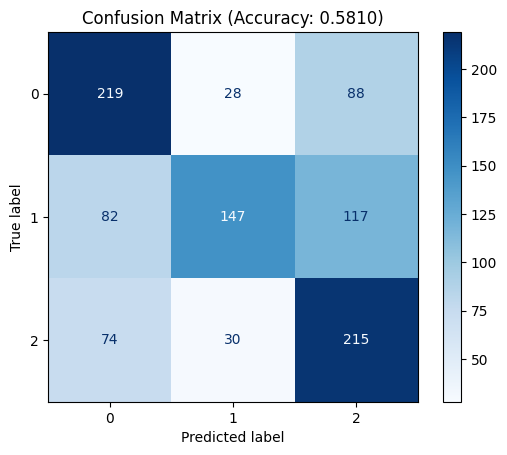

In [ ]:

labels_ = labels_[:len(slabels)]

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Calculate accuracy
accuracy = accuracy_score(labels_, slabels)
print("accuracy", accuracy)

# Generate confusion matrix
conf_matrix = confusion_matrix(labels_, slabels)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.4f})')
plt.show()


In [ ]:
# from transformers import BertTokenizer

# # Initialize the tokenizer (you can use 'bert-base-uncased' or any other pre-trained model)
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# # Define very long premise and hypothesis
# premise = "This is an example premise. "  # Repeat to make it long
# hypothesis = "This is an example hypothesis. "  # Repeat to make it long

# # Tokenize the premise and hypothesis separately with truncation
# tokenized_premise = tokenizer(premise, max_length=256, truncation=True, add_special_tokens=False)
# tokenized_hypothesis = tokenizer(hypothesis, max_length=256, truncation=True, add_special_tokens=False)

# # Combine the tokenized premise and hypothesis with [CLS] and [SEP] tokens
# input_ids = (
#     [tokenizer.cls_token_id] + 
#     tokenized_premise['input_ids'] + 
#     [tokenizer.sep_token_id] + 
#     tokenized_hypothesis['input_ids'] + 
#     [tokenizer.sep_token_id]
# )

# # Pad if necessary to the max length (512 tokens)
# input_ids = input_ids[:512]  # Truncate if the length exceeds 512

# # Convert tokens to the actual tokens (not IDs)
# tokens = tokenizer.convert_ids_to_tokens(input_ids)

# print("Token IDs:", input_ids)
# print("Tokens:", tokens)

# # Find the indices of the [SEP] tokens
# sep_indices = [i for i, token in enumerate(tokens) if token == '[SEP]']

# # Extract the tokenized premise and hypothesis
# tokenized_premise = tokens[1:sep_indices[0]]  # From [CLS] to first [SEP]
# tokenized_hypothesis = tokens[sep_indices[0] + 1:sep_indices[1]]  # Between first [SEP] and second [SEP]

# # Decode the tokens back to strings
# decoded_premise = tokenizer.convert_tokens_to_string(tokenized_premise)
# decoded_hypothesis = tokenizer.convert_tokens_to_string(tokenized_hypothesis)

# print("Decoded Premise:", decoded_premise)
# print("Decoded Hypothesis:", decoded_hypothesis)


In [ ]:
# from transformers import BertTokenizer

# # Initialize the tokenizer (you can use 'bert-base-uncased' or any other pre-trained model)
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# # Define your premise and hypothesis
# premise = "This is an example premise."
# hypothesis = "This is an example hypothesis."

# # Tokenize the premise and hypothesis with [CLS] and [SEP] tokens
# inputs = tokenizer(premise, hypothesis, return_tensors='pt')

# # Convert tokens to IDs
# input_ids = inputs['input_ids'][0]

# # Convert tokens to the actual tokens (not IDs)
# tokens = tokenizer.convert_ids_to_tokens(input_ids)

# print("Token IDs:", input_ids)
# print("Tokens:", tokens)


In [ ]:
# from transformers import BertTokenizer

# # Initialize the tokenizer (you can use 'bert-base-uncased' or any other pre-trained model)
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# # Define very long premise and hypothesis
# premise = "This is an example premise. " * 50  # Repeat to make it long
# hypothesis = "This is an example hypothesis. " * 50  # Repeat to make it long

# # Tokenize the premise and hypothesis separately with truncation
# tokenized_premise = tokenizer(premise, max_length=256, truncation=True, add_special_tokens=False)['input_ids']
# tokenized_hypothesis = tokenizer(hypothesis, max_length=256, truncation=True, add_special_tokens=False)['input_ids']

# # Convert token IDs to tokens
# tokenized_premise_tokens = tokenizer.convert_ids_to_tokens(tokenized_premise)
# tokenized_hypothesis_tokens = tokenizer.convert_ids_to_tokens(tokenized_hypothesis)

# # Combine the tokenized premise and hypothesis with [CLS] and [SEP] tokens
# tokens = ['[CLS]'] + tokenized_premise_tokens + ['[SEP]'] + tokenized_hypothesis_tokens + ['[SEP]']

# print("Tokens:", tokens)


# Confusio Matrics of Source Labels and Adversarial Labels

In [ ]:
import pandas as pd
import json
import numpy as np
# Load the JSON file directly into a DataFrame
# Step 1: Load the JSON data
# with open('/usa/taikun/07_transencoder/2evaluation/mnli/premise/evaluation_0.7_2_1000_2.9903_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json', 'r') as file:
#     data = json.load(file)

mapping = {0:'contradiction', 1:'entailment', 2:'neutral'}
revert_mapping = {'contradiction': 0, 'entailment': 1, 'neutral': 2}

# Open the text file and read the lines
with open('/usa/taikun/07_transencoder/MNLI/mnli/mnli_matched.txt', 'r') as file:
    lines = file.readlines()

# Extract the labels and map them to numbers
labels = [revert_mapping[line.split("\t")[0]] for line in lines][:999]

# # Step 2: Function to get the predicted label from probabilities
def get_predicted_label(prob_list, label_map):
    # Get the index of the highest probability
    max_index = np.argmax(prob_list)
    # Return the corresponding label
    return max_index

# # Step 2: Function to get the predicted label from probabilities
def get_predicted_label_str(prob_list, label_map):
    # Get the index of the highest probability
    max_index = np.argmax(prob_list)
    # Return the corresponding label
    return label_map[max_index]

# # Step 3: Process the JSON data
# for entry in data:
#     # Assuming 'advPredProb' and 'srcPredProb' exist in the JSON structure
#     adv_probs = entry['advPredProb']
#     entry['advLabel'] = get_predicted_label(adv_probs, label_mapping)

# df = pd.read_json(data)
df = pd.read_json('/usa/taikun/07_transencoder/2evaluation/mnli/premise/evaluation_0.7_2_1000_2.9903_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json')
df['advLabel_str'] = df['advPredProb'].apply(lambda x: get_predicted_label_str(x, mapping))
df['advLabel'] = df['advPredProb'].apply(lambda x: get_predicted_label(x, mapping))


# Display the DataFrame
df.head(2)

FileNotFoundError: File /usa/taikun/07_transencoder/2evaluation/mnli/premise/evaluation_0.7_2_1000_2.9903_BERTFineTuned_BERT_MNLI_mnli_matched_val_0.7_8_120_0.json does not exist

Accuracy: 10.11%


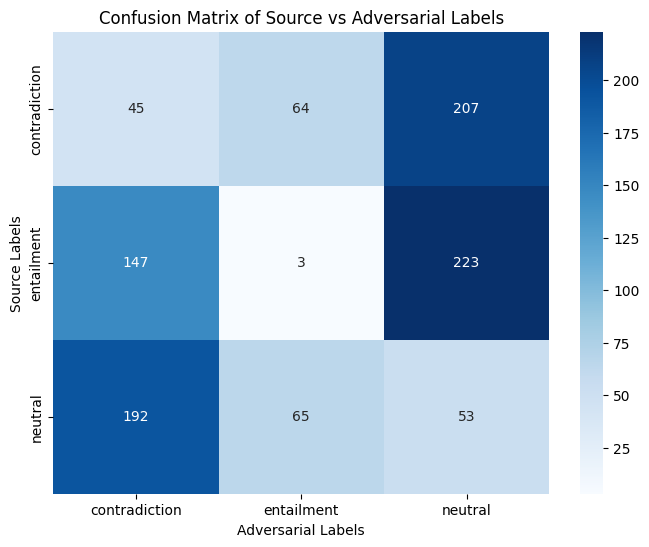

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Create confusion matrix
conf_matrix = confusion_matrix(labels, df['advLabel'])

# Step 3: Create a DataFrame for better visualization
conf_matrix_df = pd.DataFrame(conf_matrix, index=[mapping[i] for i in range(3)],
                              columns=[mapping[i] for i in range(3)])

# Calculate accuracy
correct = sum([1 for a, p in zip(labels, df['advLabel']) if a == p])  # Count matching labels
total = len(labels)  # Total number of labels
accuracy = correct / total  # Accuracy calculation
print(f"Accuracy: {accuracy * 100:.2f}%")

# Step 4: Visualize the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Adversarial Labels")
plt.ylabel("Source Labels")
plt.title("Confusion Matrix of Source vs Adversarial Labels")
plt.show()

